In [1]:

import sys  
sys.path.append('../')
from utils_models import *
with open("try_mcsolve 2024-04-18 23:59:33.pkl", 'rb') as file:
    result = pickle.load(file)

ntraj = len(result.states)
print(f'ntraj: {ntraj}')
states_array = np.array([[state.full() for state in traj] for traj in result.states])
# The following line averages over n trajectories of kets
# n is traj index, t is time index, r is row index, c is column index, i and j are the row and column index of the conjugated ket
summed_dm_array = np.einsum('ntrc,ntij->tri', states_array, states_array.conj()) 
averaged_dm_array = summed_dm_array/ntraj
result.states = [qutip.Qobj(dm) for dm in averaged_dm_array]
with open(f'try_mcsolve_leakage_summed.pkl', 'wb') as file:
    pickle.dump(result, file)


ntraj: 500


In [3]:
max_ql = 30
max_ol = 75
EJ = 3
EC = EJ/4
EL = EJ/20.5
Er = 8.46111172

g = 0.2
w_d = 8.460155465243822
amp = 0.003

tot_time =700
tlist = np.linspace(0, tot_time, tot_time)
kappa = 1e-3

system =  FluxoniumOscillatorSystem(
                EJ = EJ,
                EC = EC,
                EL = EL,
                Er = Er,
                g_strength = g, 
                qubit_level = max_ql,
                osc_level = max_ol,
                products_to_keep=[[ql, ol] for ql in [0] for ol in range(max_ol) ],
                computaional_states = '1,2',
                )

In [5]:
post_processing_funcs = []
post_processing_args = []
post_processing_funcs.append(pad_back_custom)
post_processing_args.append((system.products_to_keep, 
                            system.product_to_dressed))

post_processing_funcs.append(dressed_to_2_level_dm)
post_processing_args.append((
                            system.product_to_dressed,
                            system.qbt_position, 
                            system.filtered_product_to_dressed,
                            system.sign_multiplier,
                            None
                            ))
                
result = post_process(result,
                        post_processing_funcs,
                    post_processing_args)

Processing states with pad_back_custom:   0%|          | 0/700 [00:00<?, ?it/s]

Processing states with dressed_to_2_level_dm:   0%|          | 0/700 [00:00<?, ?it/s]

In [6]:


products_to_keep = system.products_to_keep
product_to_dressed = system.product_to_dressed
qbt_position = 0
sign_multiplier = system.sign_multiplier

def get_product(dressed_dm):
    dressed_dm_data = dressed_dm#pad_back_custom(dressed_dm, products_to_keep, product_to_dressed)
    if dressed_dm_data.shape[1] == 1:
        dressed_dm_data = qutip.ket2dm(dressed_dm_data)
    dressed_dm_data = dressed_dm_data.full()

    # Infer subsystem dimensions
    subsystem_dims = [max(indexes) + 1 for indexes in zip(*product_to_dressed.keys())]
    rho_product = np.zeros((subsystem_dims*2), dtype=complex) # Here rho_product is shaped like (dim1,dim2,dim1,dim2)
    for product_state, dressed_index1 in product_to_dressed.items():
        for product_state2, dressed_index2 in product_to_dressed.items():
            element = dressed_dm_data[dressed_index1, dressed_index2] * sign_multiplier[dressed_index1] * sign_multiplier[dressed_index2]
            rho_product[product_state+product_state2] += element # Using index like (lvl1, lvl2, lvl1, lvl2) to access of of the entries

    two_lvl_qbt_dm_size = np.prod(subsystem_dims)
    rho_product = rho_product.reshape((two_lvl_qbt_dm_size,two_lvl_qbt_dm_size))
    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])
    return rho_product


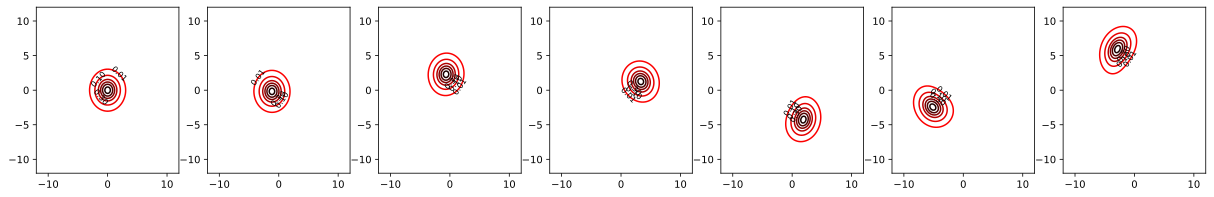

In [8]:
ts = [100,200,300,400,500,600,699]
num_times = len(ts)
fig, axes = plt.subplots(1,num_times,figsize = (3*num_times,1*3))
lim = 12
xvec = np.linspace(-1*lim, lim, 500)
X, Y = np.meshgrid(xvec, xvec)


for i, ax in enumerate(axes):
    dressed_dm = result.states_pad_back_custom[i * 100]
    rho_product = get_product(dressed_dm)
    rho = qutip.Qobj(np.array(rho_product.ptrace(1)))
    rho = rho/rho.tr()
    Q_coherent = qutip.qfunc(rho_product.ptrace(1), xvec, xvec)
    Q_coherent[Q_coherent < 0] = 0

    q_values = Q_coherent
    sorted_q = np.sort(q_values.ravel())
    cumulative_sum = np.cumsum(sorted_q)
    total_sum = cumulative_sum[-1]

    for prob in [0.99,0.9,0.7,0.5,0.3,0.1]:
        level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
        contour = ax.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
        fmt = {level_value:f'{1 - prob:.2f}'}
        ax.clabel(contour, inline=False, fontsize=8, fmt=fmt,colors='black')


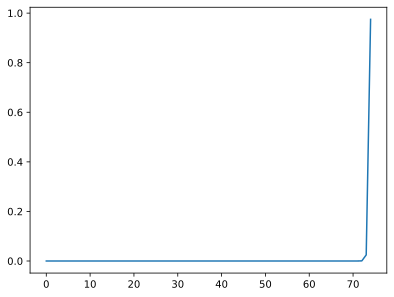

In [9]:
from qutip.sparse import eigh

values, vectors = eigh(result.states[-1].full())
plt.plot(values)